# 2. 신용정보 (신용 정보) EDA

카테고리 2 = **얼마나 빌릴 수 있나 / 금리** (여신 한도·이자율 프로필). 42개 컬럼.
라벨 `Segment`는 이 테이블에 없으므로 **회원정보(카테고리 1)에서 조인**한다.

**사전 발견**: Segment는 이용/가치 등급(A상위~E하위)의 **순서형**. 우량 고객일수록 한도가 크고 금리가 낮을 것으로 예상 → 이 카테고리로 검증.

**컬럼 구조**: 한도금액(최초/카드이용/CA/일시상환론/월상환론/B1M/B2M), 이자율(CA·CL·RV 할인전), 한도 증액·감액 이력(R12M), RV(리볼빙) 설정, 연체 여부.
⚠️ 주의: `rv최초시작후경과일`에 센티넬 `99999999`(=RV 미사용) 존재. 일부 금액 컬럼은 원(₩)이 아니라 **구간 코드**(nunique 매우 작음)로 이미 인코딩됨.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 200); pd.set_option('display.width', 220)

import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH = '201812'
SEG_ORDER = ['A','B','C','D','E']
SEG_COLORS = {'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 신용정보) + 라벨 조인 (회원정보)

In [2]:
f2 = glob.glob(os.path.join(ROOT,'train','2.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f2)
f1 = glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0]
lbl = pd.read_parquet(f1, columns=['ID','Segment'])
df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all()
print('shape:', df.shape)
df.head(3)

shape: (400000, 43)


,기준년월,ID,최초한도금액,카드이용한도금액,CA한도금액,일시상환론한도금액,월상환론한도금액,CA이자율_할인전,CL이자율_할인전,RV일시불이자율_할인전,RV현금서비스이자율_할인전,RV신청일자,RV약정청구율,RV최소결제비율,자발한도감액횟수_R12M,자발한도감액금액_R12M,자발한도감액후경과월,강제한도감액횟수_R12M,강제한도감액금액_R12M,강제한도감액후경과월,한도증액횟수_R12M,한도증액금액_R12M,한도증액후경과월,상향가능한도금액,상향가능CA한도금액,카드론동의여부,월상환론상향가능한도금액,RV전환가능여부,일시불ONLY전환가능여부,카드이용한도금액_B1M,카드이용한도금액_B2M,특별한도보유여부_R3M,연체감액여부_R3M,한도심사요청건수,한도요청거절건수,한도심사요청후경과월,한도심사거절후경과월,시장단기연체여부_R6M,시장단기연체여부_R3M,시장연체상환여부_R6M,시장연체상환여부_R3M,rv최초시작후경과일,Segment
0,201812,TRAIN_000000,0,19507,5795,0,0,22.996676,18.561064,18.407148,21.203381,NaN,0.0000,19.99996,0회,0,12,0,0,12,0회,0,12,0,0,Y,0,N,0,20665,20690,0,0,0회,0,3,3,0,0,0,0,99999999,D
1,201812,TRAIN_000001,0,9997,4236,42330,92751,14.817007,15.521311,11.042575,13.656718,20180311.0,99.9998,9.99998,0회,0,12,0,0,12,0회,0,12,3,1,Y,0,Z,1,10001,10000,0,0,0회,0,3,3,0,0,0,0,325,E
2,201812,TRAIN_000002,0,86975,28985,0,0,22.265409,18.064661,17.426129,21.224464,20120323.0,99.9998,19.99996,0회,0,12,1,1,12,0회,0,12,0,0,Y,0,N,0,76596,77033,0,0,0회,0,3,3,0,0,0,0,2438,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'missing_%': (df.isna().mean()*100).round(2),
    'nunique': df.nunique(dropna=True),
})
meta.sort_values(['nunique','missing_%'])

,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.00,1
특별한도보유여부_R3M,int64,0,0.00,1
한도심사요청건수,str,0,0.00,1
한도요청거절건수,int64,0,0.00,1
한도심사요청후경과월,int64,0,0.00,1
한도심사거절후경과월,int64,0,0.00,1
시장단기연체여부_R3M,int64,0,0.00,1
시장연체상환여부_R6M,int64,0,0.00,1
시장연체상환여부_R3M,int64,0,0.00,1
한도증액횟수_R12M,str,0,0.00,2


### 2-1. 버릴 후보 — 상수 컬럼 & 고결측 컬럼

In [4]:
const_cols = meta.index[meta['nunique'] <= 1].tolist()
high_missing = meta.index[meta['missing_%'] >= 40].tolist()
print(f'상수 컬럼 {len(const_cols)}개 (분산 0 → 제거):'); print(const_cols)
print(f'\n고결측(>=40%) {len(high_missing)}개:')
print(meta.loc[high_missing, ['missing_%','nunique']].to_string())

상수 컬럼 9개 (분산 0 → 제거):
['기준년월', '특별한도보유여부_R3M', '한도심사요청건수', '한도요청거절건수', '한도심사요청후경과월', '한도심사거절후경과월', '시장단기연체여부_R3M', '시장연체상환여부_R6M', '시장연체상환여부_R3M']

고결측(>=40%) 1개:
        missing_%  nunique
RV신청일자      81.41     1108


## 3. 세그먼트별 한도 & 이자율 (핵심 지표)

가설: 우량(A)일수록 **한도 大 / 금리 低**. 센티넬(99999999)은 NaN 처리 후 중앙값 비교.

In [5]:
dfx = df.copy()
# 센티넬 처리
if 'rv최초시작후경과일' in dfx: dfx.loc[dfx['rv최초시작후경과일']>=99999999,'rv최초시작후경과일']=np.nan

limit_cols = [c for c in ['최초한도금액','카드이용한도금액','CA한도금액','일시상환론한도금액','월상환론한도금액'] if c in dfx]
rate_cols  = [c for c in ['CA이자율_할인전','CL이자율_할인전','RV일시불이자율_할인전','RV현금서비스이자율_할인전'] if c in dfx]

print('=== 한도금액 세그먼트별 중앙값 (₩) ===')
print(dfx.groupby('Segment')[limit_cols].median().reindex(SEG_ORDER).T.to_string())
print('\n=== 이자율 세그먼트별 중앙값 (%) ===')
print(dfx.groupby('Segment')[rate_cols].median().reindex(SEG_ORDER).round(2).T.to_string())

=== 한도금액 세그먼트별 중앙값 (₩) ===


Segment           A        B         C         D        E
최초한도금액          0.0      0.0       0.0       0.0      0.0
카드이용한도금액   200964.5  90758.0   86526.0   52437.0  40478.0
CA한도금액      57925.5  36875.5   29595.0   20540.0  11719.0
일시상환론한도금액       0.0      0.0       0.0       0.0      0.0
월상환론한도금액   157728.5      0.0  155239.0  154674.0  93918.0

=== 이자율 세그먼트별 중앙값 (%) ===
Segment             A      B      C      D      E
CA이자율_할인전       15.22  20.67  15.22  15.21  15.19
CL이자율_할인전       15.30  17.66  15.30  15.30  15.29
RV일시불이자율_할인전    11.19  13.95  11.24  11.10  11.01
RV현금서비스이자율_할인전  13.64  16.70  13.63  13.63  13.62


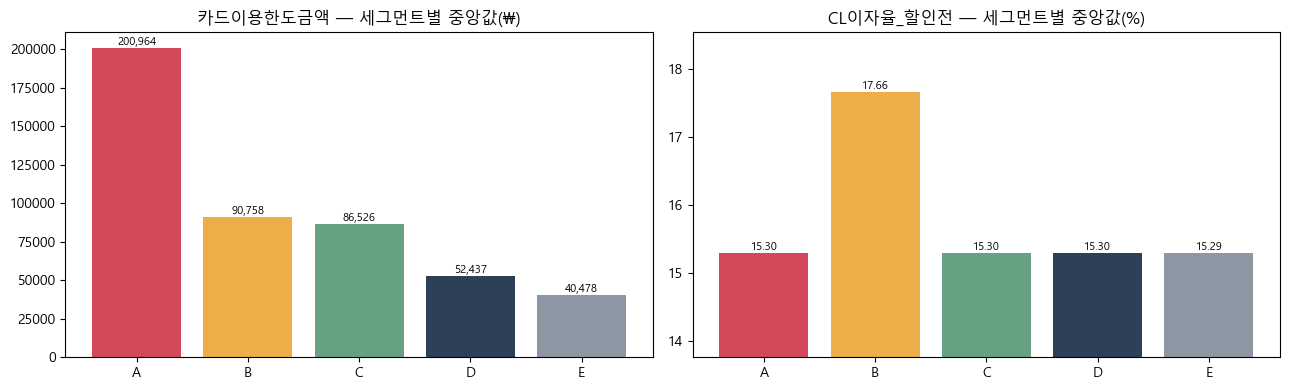

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
m1 = dfx.groupby('Segment')['카드이용한도금액'].median().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, m1.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('카드이용한도금액 — 세그먼트별 중앙값(₩)')
for i,v in enumerate(m1.values): ax[0].text(i,v,f'{v:,.0f}',ha='center',va='bottom',fontsize=8)
rc = 'CL이자율_할인전' if 'CL이자율_할인전' in dfx else rate_cols[0]
m2 = dfx.groupby('Segment')[rc].median().reindex(SEG_ORDER)
ax[1].bar(SEG_ORDER, m2.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[1].set_title(f'{rc} — 세그먼트별 중앙값(%)'); ax[1].set_ylim(bottom=min(m2)*0.9)
for i,v in enumerate(m2.values): ax[1].text(i,v,f'{v:.2f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()

## 4. Segment를 잘 가르는 수치형 피처 랭킹

In [7]:
drop = set(const_cols) | {'기준년월'}
num_cols = [c for c in dfx.columns
            if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(dfx[c])]
print('수치형 분석 대상:', len(num_cols))
med = dfx.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T
iqr = (dfx[num_cols].quantile(0.75)-dfx[num_cols].quantile(0.25)).replace(0,np.nan)
sep = ((med.max(axis=1)-med.min(axis=1))/(iqr+1e-9)).sort_values(ascending=False)
med_sorted = med.loc[sep.index]; med_sorted.insert(0,'sep_score',sep.round(2))
def monotonic(row):
    v=row.values.astype(float); return np.all(np.diff(v)<=0) or np.all(np.diff(v)>=0)
med_sorted['monotonic'] = med.loc[sep.index].apply(monotonic, axis=1)
print('분리도 상위 (세그먼트별 중앙값, monotonic=A→E 완전 단조 여부):')
med_sorted.head(20)

수치형 분석 대상: 28


분리도 상위 (세그먼트별 중앙값, monotonic=A→E 완전 단조 여부):


Segment,sep_score,A,B,C,D,E,monotonic
CA이자율_할인전,8.85,1.522166e+01,2.067014e+01,1.522155e+01,1.521243e+01,1.519355e+01,False
카드이용한도금액,4.28,2.009645e+05,9.075800e+04,8.652600e+04,5.243700e+04,4.047800e+04,True
카드이용한도금액_B2M,3.34,2.021825e+05,8.378850e+04,7.709500e+04,6.275000e+04,3.574100e+04,True
카드이용한도금액_B1M,3.31,2.012895e+05,8.428200e+04,7.734500e+04,6.291800e+04,3.571800e+04,True
CA한도금액,2.29,5.792550e+04,3.687550e+04,2.959500e+04,2.054000e+04,1.171900e+04,True
RV현금서비스이자율_할인전,2.14,1.363872e+01,1.669783e+01,1.363371e+01,1.362926e+01,1.361715e+01,False
RV일시불이자율_할인전,1.80,1.118639e+01,1.394592e+01,1.124316e+01,1.110468e+01,1.101040e+01,False
월상환론한도금액,0.98,1.577285e+05,0.000000e+00,1.552390e+05,1.546740e+05,9.391800e+04,False
상향가능한도금액,0.67,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,True
CL이자율_할인전,0.63,1.530027e+01,1.765530e+01,1.529927e+01,1.529554e+01,1.529134e+01,False


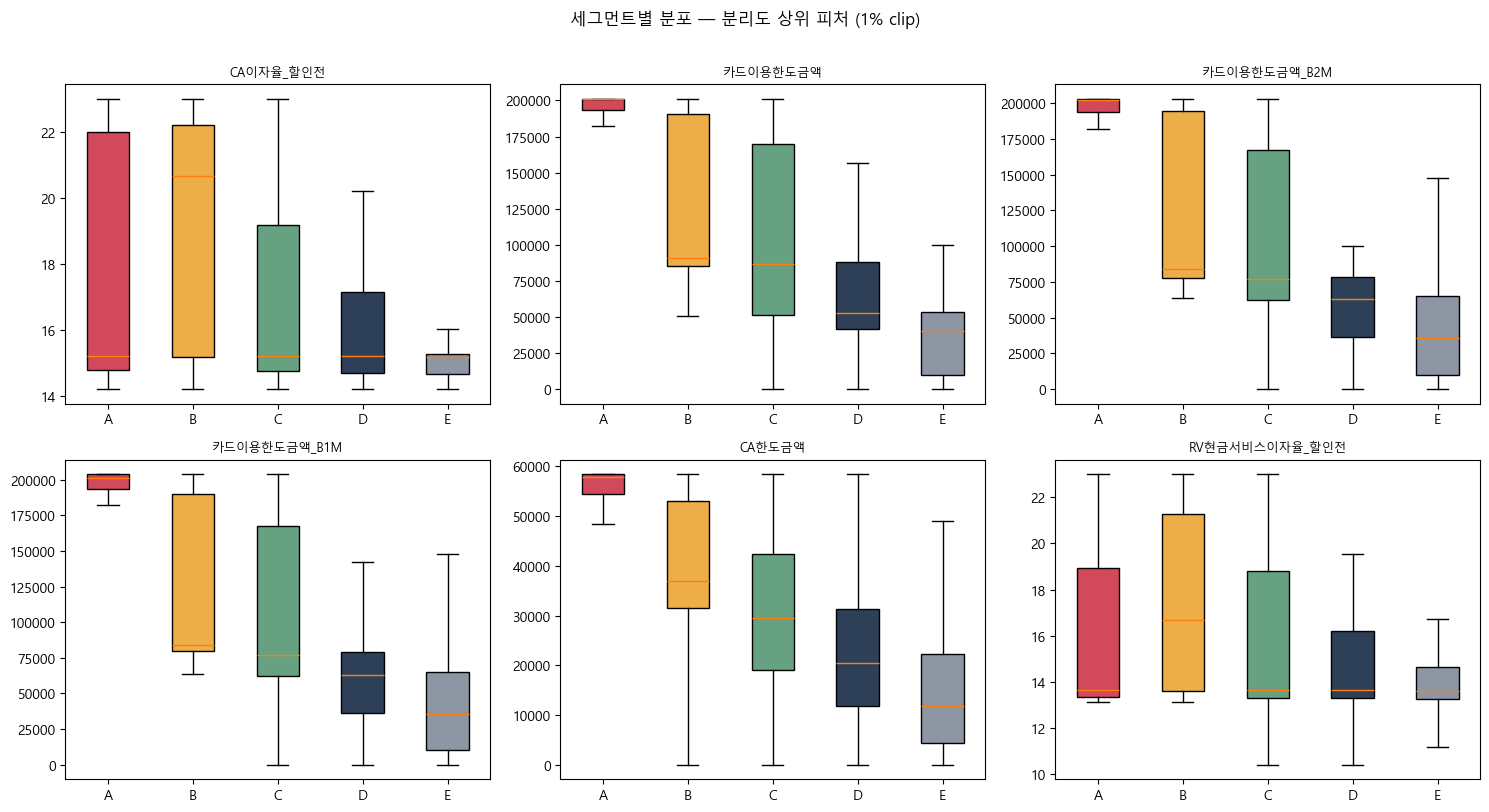

In [8]:
top_feats = sep.index[:6].tolist()
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, feat in zip(axes.ravel(), top_feats):
    q99=dfx[feat].quantile(0.99)
    data=[dfx.loc[dfx['Segment']==s, feat].clip(upper=q99) for s in SEG_ORDER]
    bp=ax.boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
    for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
    ax.set_title(feat, fontsize=9)
plt.suptitle('세그먼트별 분포 — 분리도 상위 피처 (1% clip)', y=1.01)
plt.tight_layout(); plt.show()

## 5. 범주형 / 이력성 피처 vs Segment

한도 증액·감액 이력, 카드론 동의, RV 전환 가능 여부 등이 세그먼트와 얽히는지.

In [9]:
cat_cols = [c for c in ['한도증액횟수_R12M','자발한도감액횟수_R12M','카드론동의여부',
                        'RV전환가능여부','일시불ONLY전환가능여부','연체감액여부_R3M','RV최소결제비율'] if c in df.columns]
for c in cat_cols:
    ct = pd.crosstab(df[c], df['Segment']).reindex(columns=SEG_ORDER, fill_value=0)
    row_pct=(ct.div(ct.sum(axis=1),axis=0)*100).round(1)
    out=row_pct.copy(); out['n']=ct.sum(axis=1)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) ===')
    print(out.sort_values('n',ascending=False).to_string())


=== 한도증액횟수_R12M : 값별 세그먼트 구성비(%) ===
Segment        A    B    C     D     E       n
한도증액횟수_R12M                                   
0회           0.0  0.0  5.1  13.8  81.1  351199
1회이상         0.1  0.0  6.8  20.3  72.8   48801

=== 자발한도감액횟수_R12M : 값별 세그먼트 구성비(%) ===
Segment          A    B    C     D      E       n
자발한도감액횟수_R12M                                    
0회             0.0  0.0  5.3  14.6   80.1  399866
1회             0.0  0.0  3.8  15.9   80.3     132
2회             0.0  0.0  0.0   0.0  100.0       2



=== 카드론동의여부 : 값별 세그먼트 구성비(%) ===
Segment    A    B    C     D     E       n
카드론동의여부                                   
Y        0.0  0.0  5.7  14.8  79.5  319744
N        0.0  0.0  3.8  13.7  82.5   80256

=== RV전환가능여부 : 값별 세그먼트 구성비(%) ===
Segment     A    B    C     D     E       n
RV전환가능여부                                   
Z         0.0  0.0  5.1  14.5  80.3  325657
N         0.0  0.0  7.1  16.5  76.3   65045



=== 일시불ONLY전환가능여부 : 값별 세그먼트 구성비(%) ===
Segment          A    B    C     D     E       n
일시불ONLY전환가능여부                                   
1              0.0  0.0  5.1  14.5  80.3  325525
0              0.0  0.0  6.3  14.6  79.0   74475

=== 연체감액여부_R3M : 값별 세그먼트 구성비(%) ===
Segment       A    B    C     D     E       n
연체감액여부_R3M                                   
0           0.0  0.0  5.3  14.5  80.1  397794
1           0.0  0.0  6.0  23.3  70.7    2206

=== RV최소결제비율 : 값별 세그먼트 구성비(%) ===
Segment     A    B     C     D     E       n
RV최소결제비율                                    
9.99998   0.0  0.0   5.4  15.2  79.4  288659
19.99996  0.0  0.0   7.0  17.4  75.6   63587
14.99997  0.0  0.0   2.9   8.0  89.1   36818
0.00000   0.0  0.0   0.3   1.3  98.4    9297
24.99995  0.2  0.0  11.2  20.1  68.4    1629
29.99994  0.0  0.0  10.0  10.0  80.0      10


## 6. 소수클래스 A / B 집중

In [10]:
glob_med = dfx[num_cols].median(); a_med=dfx[dfx['Segment']=='A'][num_cols].median(); b_med=dfx[dfx['Segment']=='B'][num_cols].median()
cmp = pd.DataFrame({'A_median':a_med,'B_median':b_med,'ALL_median':glob_med})
cmp['A_over_ALL']=(a_med/glob_med.replace(0,np.nan)).round(2)
cmp['B_over_ALL']=(b_med/glob_med.replace(0,np.nan)).round(2)
cmp['A_vs_B_absdiff']=(a_med-b_med).abs()
print('=== A/B가 전체 대비 특이한 피처 (A_over_ALL 기준 상위) ===')
print(cmp.sort_values('A_over_ALL',ascending=False).head(12).to_string())
print('\n=== A vs B 차이 큰 피처 (분리 후보) ===')
print(cmp.sort_values('A_vs_B_absdiff',ascending=False).head(12)[['A_median','B_median','A_vs_B_absdiff']].to_string())

=== A/B가 전체 대비 특이한 피처 (A_over_ALL 기준 상위) ===
                    A_median      B_median    ALL_median  A_over_ALL  B_over_ALL  A_vs_B_absdiff
카드이용한도금액_B2M    2.021825e+05  8.378850e+04  3.698700e+04        5.47        2.27   118394.000000
카드이용한도금액_B1M    2.012895e+05  8.428200e+04  3.700000e+04        5.44        2.28   117007.500000
카드이용한도금액        2.009645e+05  9.075800e+04  4.307250e+04        4.67        2.11   110206.500000
CA한도금액          5.792550e+04  3.687550e+04  1.383900e+04        4.19        2.66    21050.000000
월상환론한도금액        1.577285e+05  0.000000e+00  1.489280e+05        1.06        0.00   157728.500000
rv최초시작후경과일      8.810000e+02  8.290000e+02  8.450000e+02        1.04        0.98       52.000000
RV일시불이자율_할인전    1.118639e+01  1.394592e+01  1.103122e+01        1.01        1.26        2.759526
RV현금서비스이자율_할인전  1.363872e+01  1.669783e+01  1.362031e+01        1.00        1.23        3.059111
RV신청일자          2.016082e+07  2.016091e+07  2.016092e+07        1.00        1.00  

## 7. 요약 & 발견

### 한도(限度)는 순서형(A→E) 성립, 이자율은 아님
- **카드이용한도금액**이 A→E 완전 단조: 중앙값 **A 200,964 → B 90,758 → C 86,526 → D 52,437 → E 40,478**. (`_B1M/_B2M`, `CA한도금액`도 동일 단조.) → 한도는 순서형 가설에 부합하는 좋은 피처.
- **이자율(CA/CL/RV)은 단조 아님.** A·C·D·E는 모두 ~15.2%로 거의 동일 → 이자율은 등급을 못 가름.

### ★ 새 발견 — **B(24명)의 지문(fingerprint)이 처음으로 잡힘**
회원정보·승인매출에선 A와 B가 안 갈렸는데, 신용정보에서 B가 뚜렷이 튄다:
- **B의 이자율이 유독 높음**: CA 20.67% vs 나머지 ~15.2 / CL 17.66 vs 15.3 / RV 13.95·16.70 vs 11.1·13.6. (그래서 `CA이자율_할인전`이 분리도 1위 8.85지만 '단조'가 아님 — B만 솟음.)
- **B는 `월상환론한도금액`=0** (A는 157,728). A vs B 최대 차이 피처.
→ **B ≈ 한도는 중상위지만 고금리 + 카드론(월상환론) 한도 없음.** 이 조합이 B를 few-shot으로 잡는 단서. 신용정보는 **A/B 분리에 실질 기여하는 첫 카테고리.**

### A의 특징
A는 한도가 압도적으로 큼(카드이용한도 201k, 전체 중앙값 대비 4.7배; 월상환론한도 157k 보유). 고한도가 A의 표식.

### 범주형 신호(약함)
한도증액/감액 이력, 카드론동의, RV전환 등은 세그먼트 구성비가 전체(E80/D15/C5)와 크게 다르지 않아 신호 약함. `RV최소결제비율`=0(=완납형)은 E 98%로 저이용층 쏠림 정도.

### 전처리 메모
- **상수 컬럼 9개** 제거(특별한도보유여부, 한도심사 계열 4개, 시장연체 일부).
- 고결측 `RV신청일자`(81%)=RV 미신청 → 결측 플래그.
- `rv최초시작후경과일` 센티넬 99999999(=RV미사용)는 NaN/플래그 분리 필수.
- `최초한도금액`·`일시상환론한도금액`·`RV약정청구율` 등은 중앙값 0(대부분 0) — 저정보이나 상위 세그에서만 값 존재할 수 있어 유지 검토.

**다음 카테고리**: 4.청구입금정보 (03 승인매출에서 정상입금원금이 강력했음).